In [25]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# =====================================================
# LOAD DATASET
# =====================================================

DATA_PATH = "diabeticsUserData.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 26)


,age,gender,height_cm,weight_kg,bmi,physical_activity_level,steps_per_day,sleep_hours,diabetes_duration_years,hba1c_percent,...,diastolic_bp_mmHg,egfr_ml_min_1_73m2,smoking_status,alcohol_use,primary_goal,daily_calories_kcal,daily_carbohydrates_g,daily_protein_g,daily_fat_g,daily_fiber_g
0,60,Female,156.4,59.7,24.4,Sedentary,2310,6.1,5.7,8.23,...,57.7,63.1,0,0,Maintenance,1200.0,117.2,55.5,52.6,33.4
1,73,Male,171.1,79.8,27.3,Light,5922,6.3,1.5,6.83,...,82.5,79.0,1,0,Maintenance,1857.6,225.0,85.9,64.8,34.0
2,33,Male,170.8,74.2,25.4,Light,4081,6.6,3.1,7.72,...,58.6,92.0,0,0,Glycemic control,2253.1,229.3,112.7,98.4,30.1
3,51,Male,164.4,82.7,30.6,Moderate,11014,6.4,1.2,7.50,...,66.4,91.3,0,0,Weight loss,2112.2,230.3,105.6,77.1,32.4
4,53,Female,156.0,78.3,32.2,Moderate,9193,4.6,1.7,6.72,...,77.1,86.8,1,0,Glycemic control,1949.6,200.6,87.7,88.5,35.1


In [3]:
# =====================================================
# DATASET INFO
# =====================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         10000 non-null  int64  
 1   gender                      10000 non-null  str    
 2   height_cm                   10000 non-null  float64
 3   weight_kg                   10000 non-null  float64
 4   bmi                         10000 non-null  float64
 5   physical_activity_level     10000 non-null  str    
 6   steps_per_day               10000 non-null  int64  
 7   sleep_hours                 10000 non-null  float64
 8   diabetes_duration_years     10000 non-null  float64
 9   hba1c_percent               10000 non-null  float64
 10  fasting_glucose_mg_dl       10000 non-null  float64
 11  postprandial_glucose_mg_dl  10000 non-null  float64
 12  triglycerides_mg_dl         10000 non-null  float64
 13  ldl_cholesterol_mg_dl       10000 non-null 

In [4]:
# =====================================================
# DESCRIPTIVE STATISTICS
# =====================================================

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,10000.0,NaN,NaN,NaN,48.751,17.770711,18.0,33.0,49.0,64.0,79.0
gender,10000,2,Male,5479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,10000.0,NaN,NaN,NaN,164.65999,8.84651,145.0,158.0,164.3,171.1,190.0
weight_kg,10000.0,NaN,NaN,NaN,76.28225,13.647876,45.0,66.6,75.4,85.0,134.8
bmi,10000.0,NaN,NaN,NaN,28.04732,3.973254,18.0,25.3,28.0,30.7,42.0
physical_activity_level,10000,4,Sedentary,3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
steps_per_day,10000.0,NaN,NaN,NaN,6155.5423,2978.029282,800.0,3866.5,5664.0,8004.0,18211.0
sleep_hours,10000.0,NaN,NaN,NaN,6.78246,1.096918,4.0,6.0,6.8,7.5,9.5
diabetes_duration_years,10000.0,NaN,NaN,NaN,3.20503,3.373793,0.0,0.0,2.3,5.4,17.3
hba1c_percent,10000.0,NaN,NaN,NaN,7.823412,1.165936,5.6,7.0,7.825,8.61,12.12


In [23]:
# =====================================================
# MISSING VALUES ANALYSIS (SAFE VERSION)
# =====================================================

missing = df.isnull().sum().sort_values(ascending=False)

print("Missing Values Per Column:")
display(missing)

missing_nonzero = missing[missing > 0]

if len(missing_nonzero) > 0:
    plt.figure(figsize=(12,6))
    missing_nonzero.plot(kind="bar")
    plt.title("Missing Values Count")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("✅ No missing values found in dataset.")

Missing Values Per Column:


age                           0
gender                        0
height_cm                     0
weight_kg                     0
bmi                           0
physical_activity_level       0
steps_per_day                 0
sleep_hours                   0
diabetes_duration_years       0
hba1c_percent                 0
fasting_glucose_mg_dl         0
postprandial_glucose_mg_dl    0
triglycerides_mg_dl           0
ldl_cholesterol_mg_dl         0
hdl_cholesterol_mg_dl         0
systolic_bp_mmHg              0
diastolic_bp_mmHg             0
egfr_ml_min_1_73m2            0
smoking_status                0
alcohol_use                   0
primary_goal                  0
daily_calories_kcal           0
daily_carbohydrates_g         0
daily_protein_g               0
daily_fat_g                   0
daily_fiber_g                 0
dtype: int64

✅ No missing values found in dataset.


In [6]:
# =====================================================
# DUPLICATES CHECK
# =====================================================

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [24]:
# =====================================================
# FEATURE TYPE SPLIT
# =====================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(cat_cols))

Numeric Columns: 23
Categorical Columns: 3


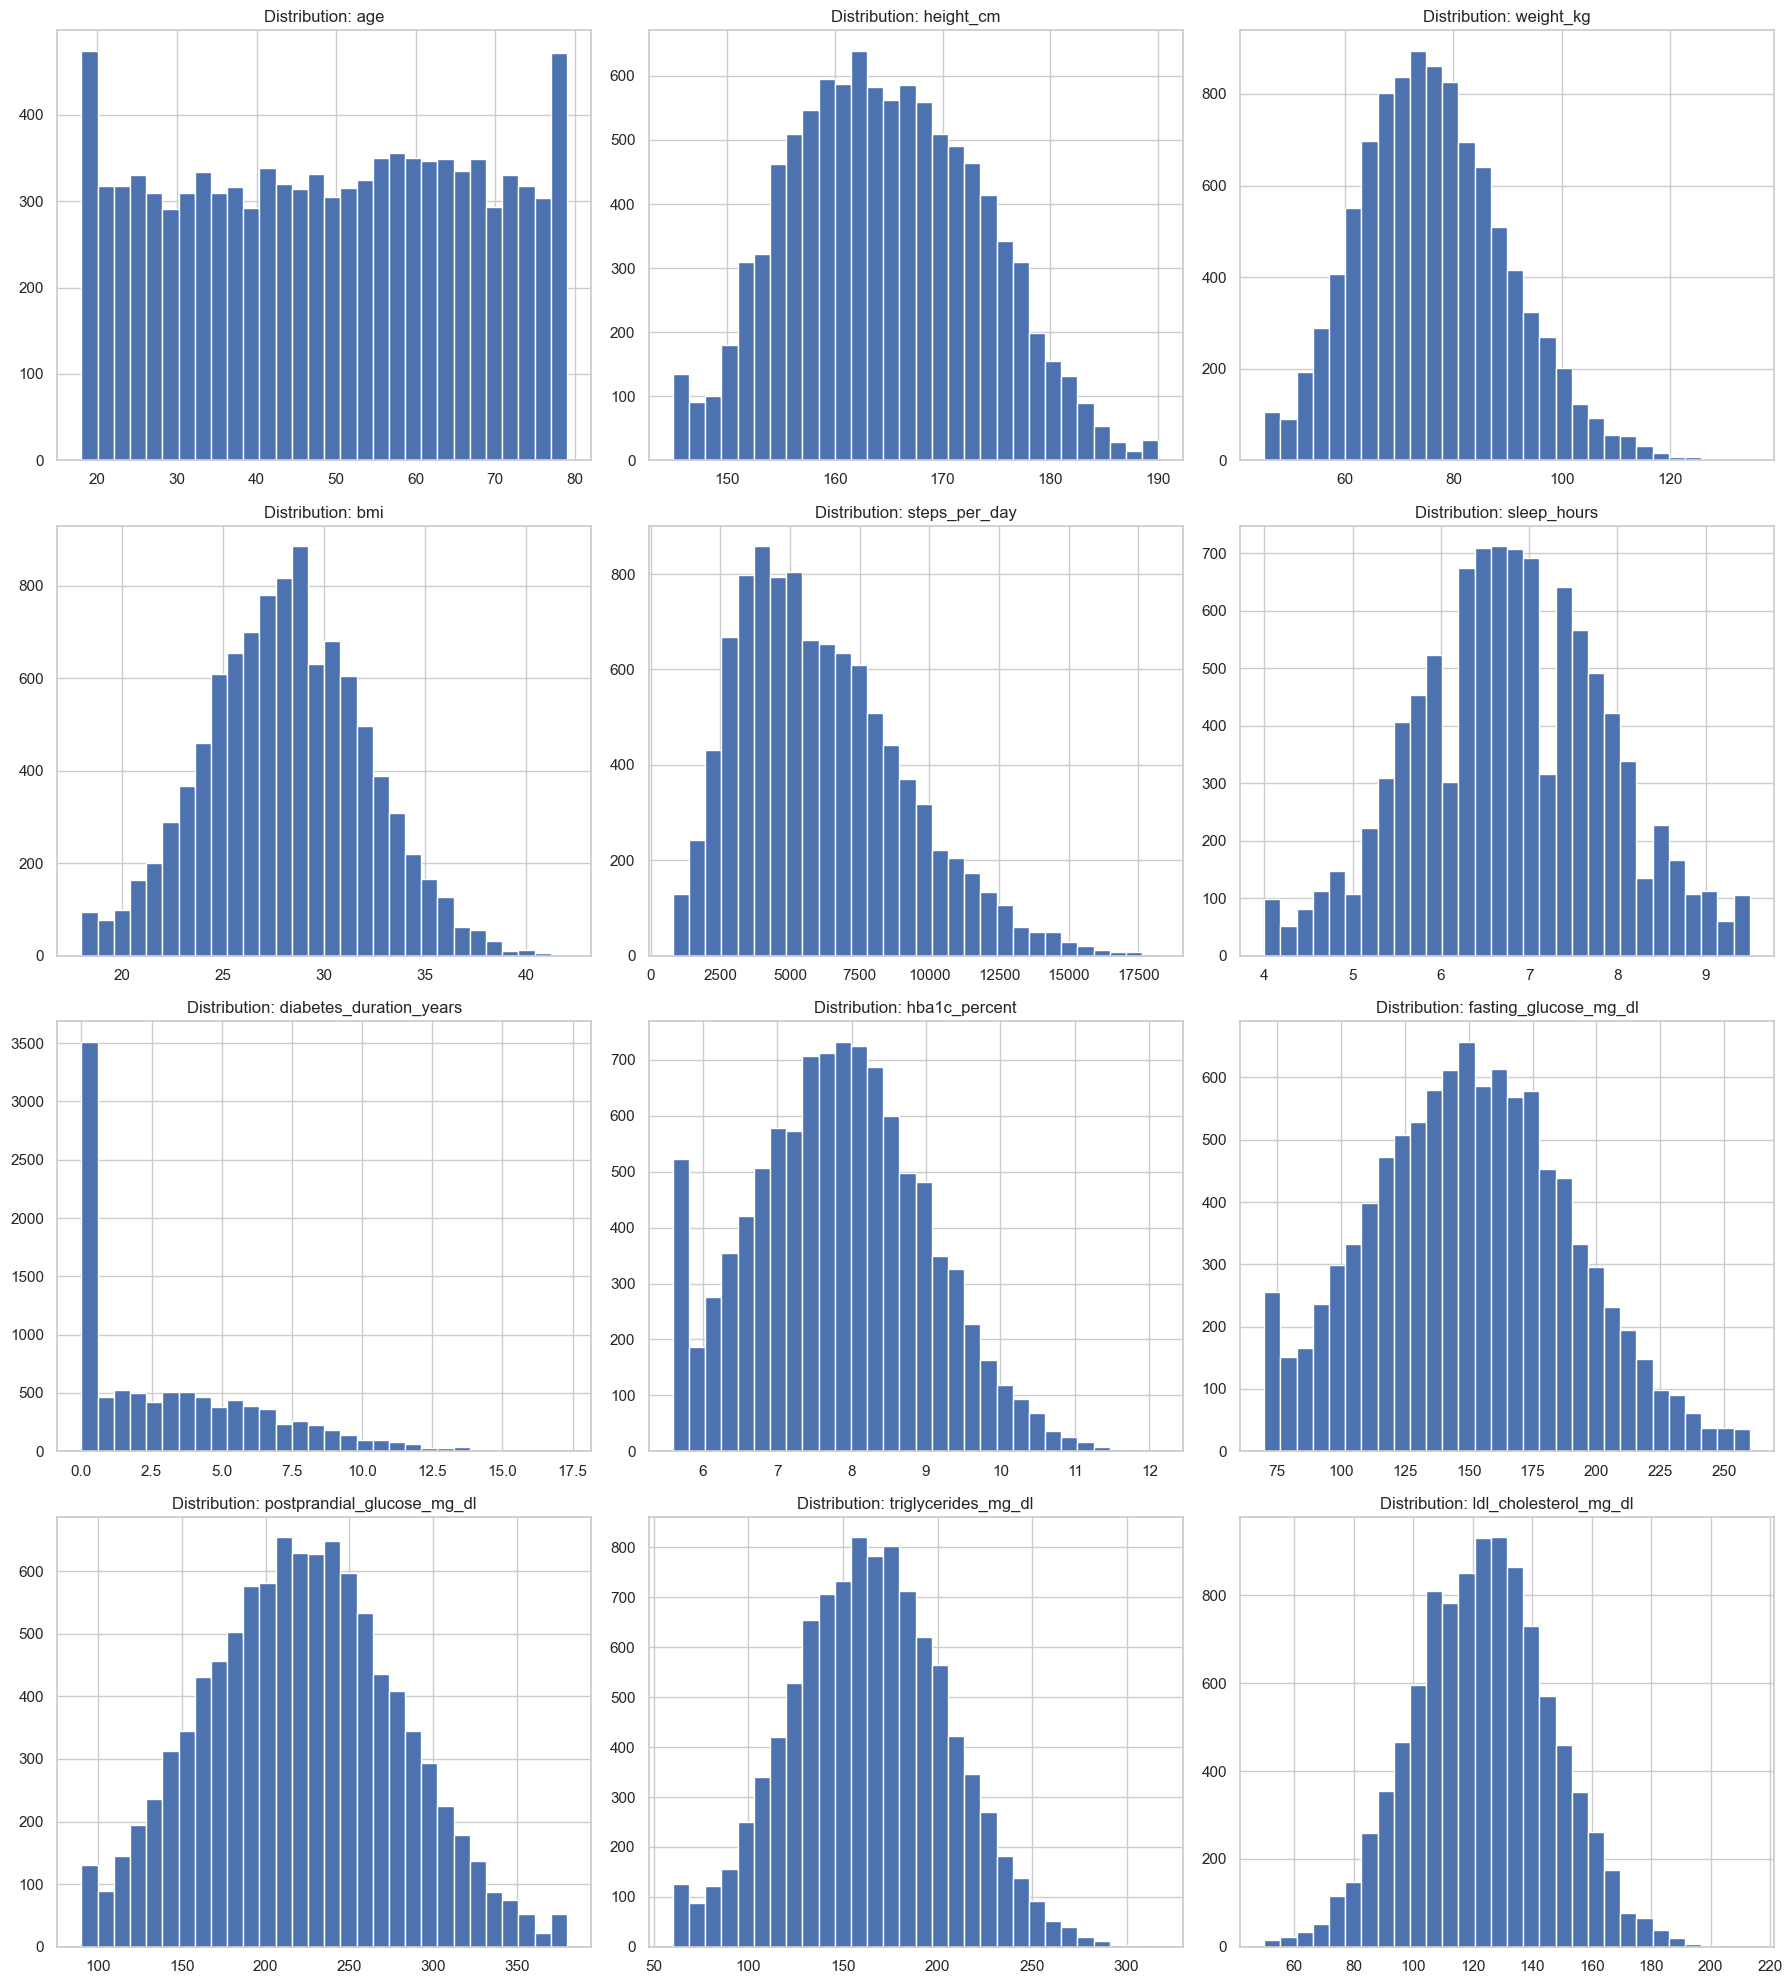

In [8]:
# =====================================================
# NUMERIC DISTRIBUTIONS
# =====================================================

num_subset = numeric_cols[:12]  # first 12 for cleaner visualization

n_cols = 3
n_rows = math.ceil(len(num_subset) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_subset):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(f"Distribution: {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

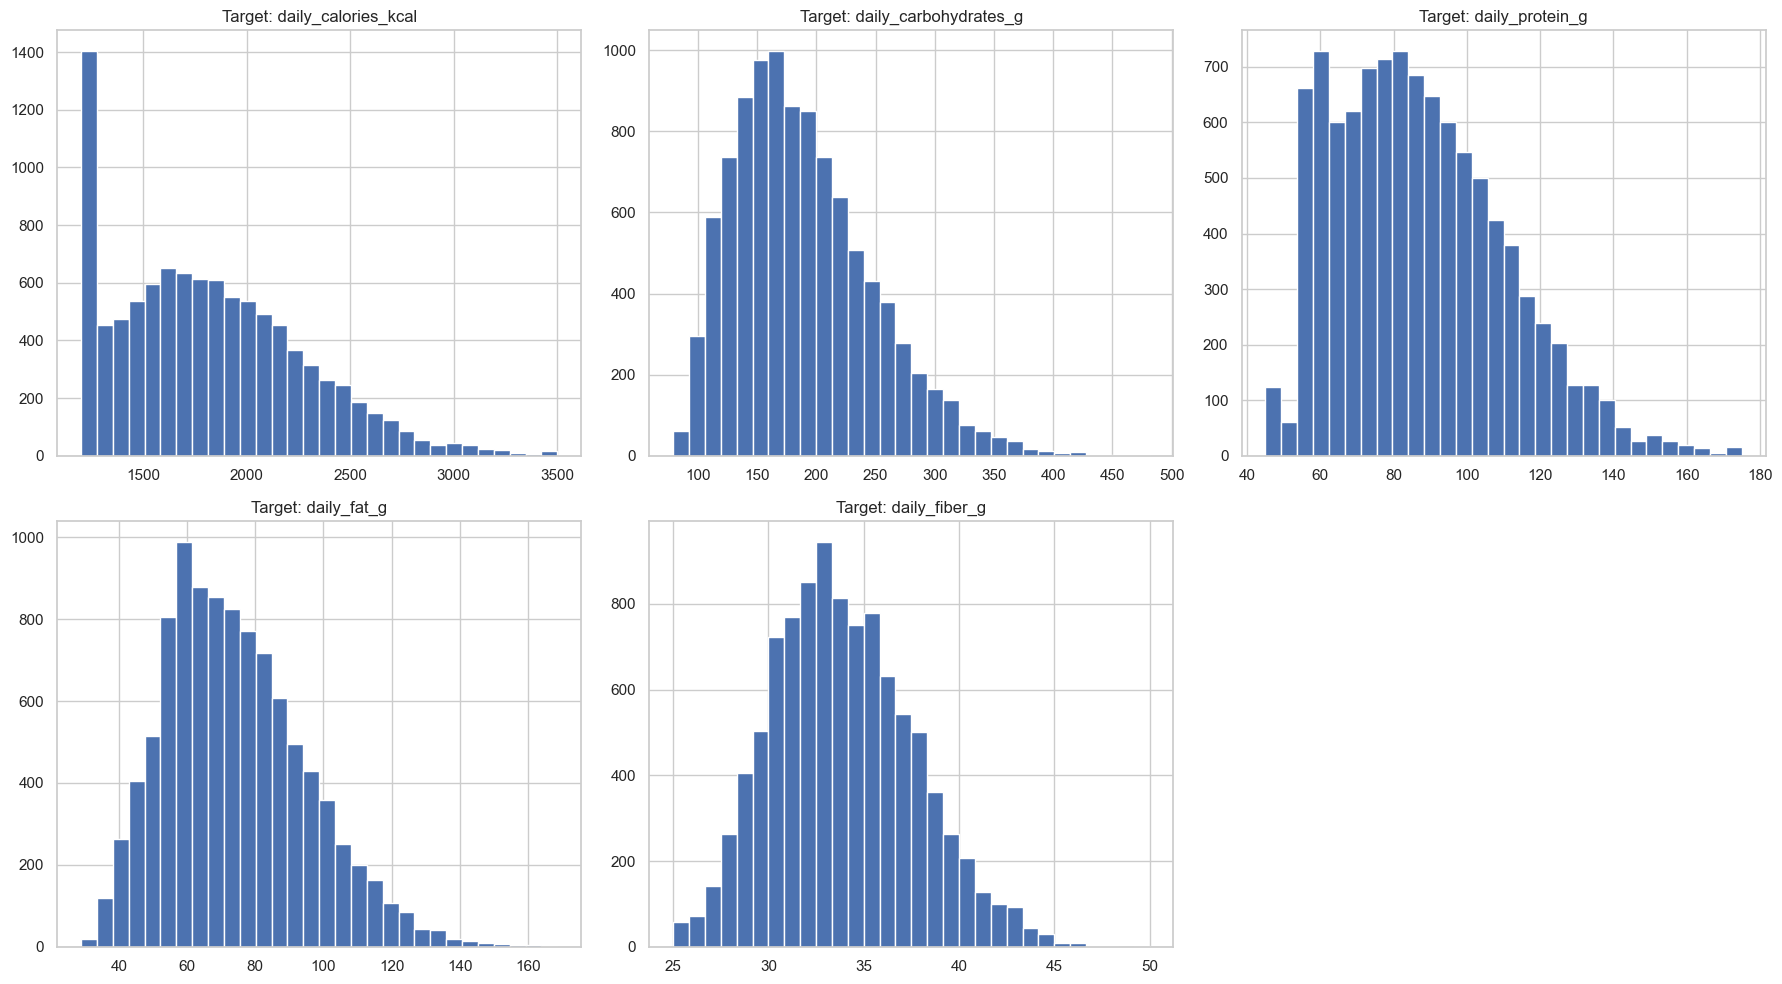

In [9]:
# =====================================================
# TARGET DISTRIBUTION
# =====================================================

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

targets_present = [t for t in TARGET_COLS if t in df.columns]

n_cols = 3
n_rows = math.ceil(len(targets_present) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(targets_present):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(f"Target: {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

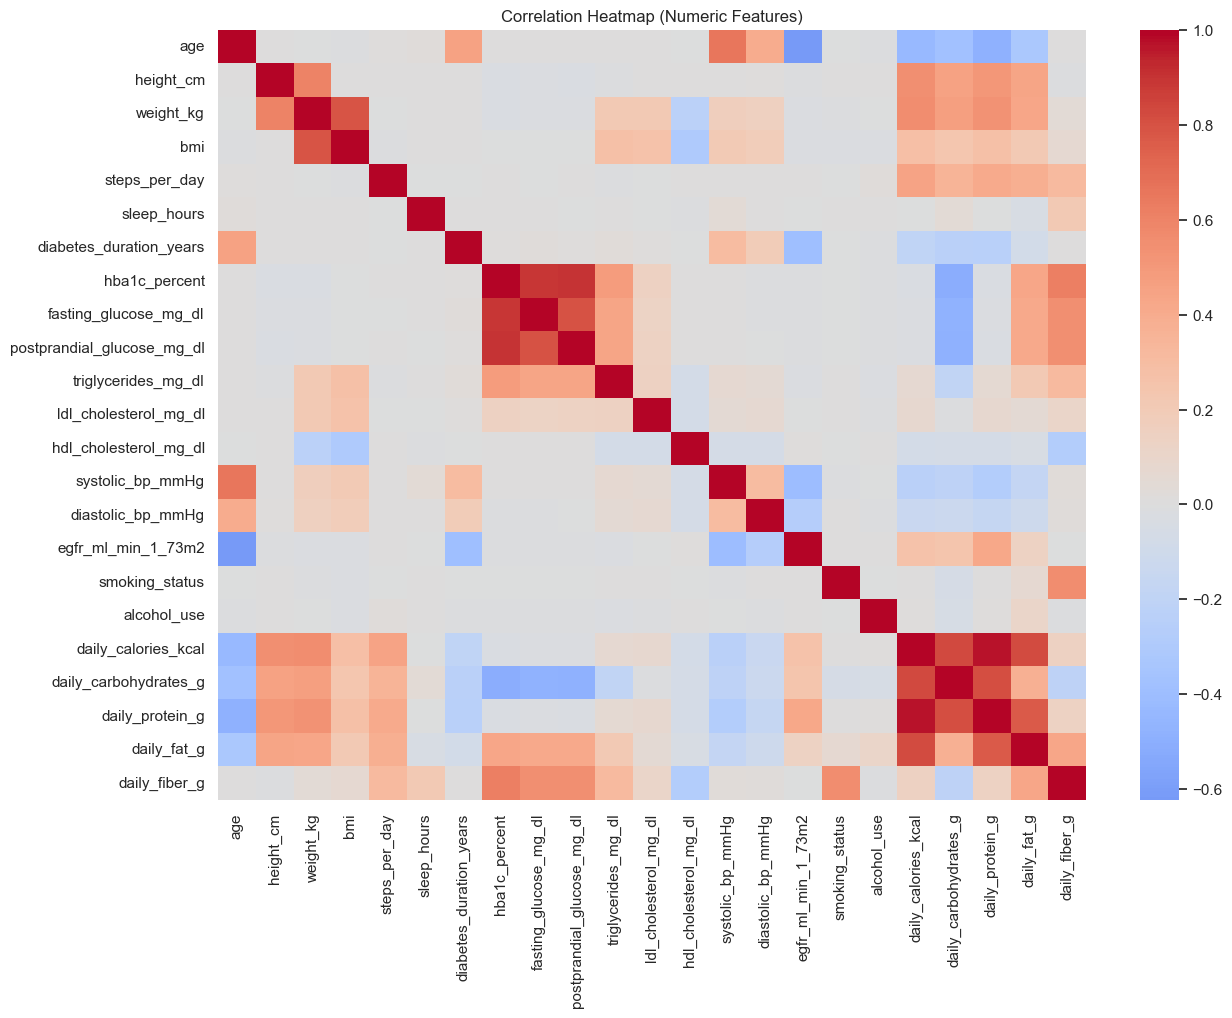

In [10]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

corr = df[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

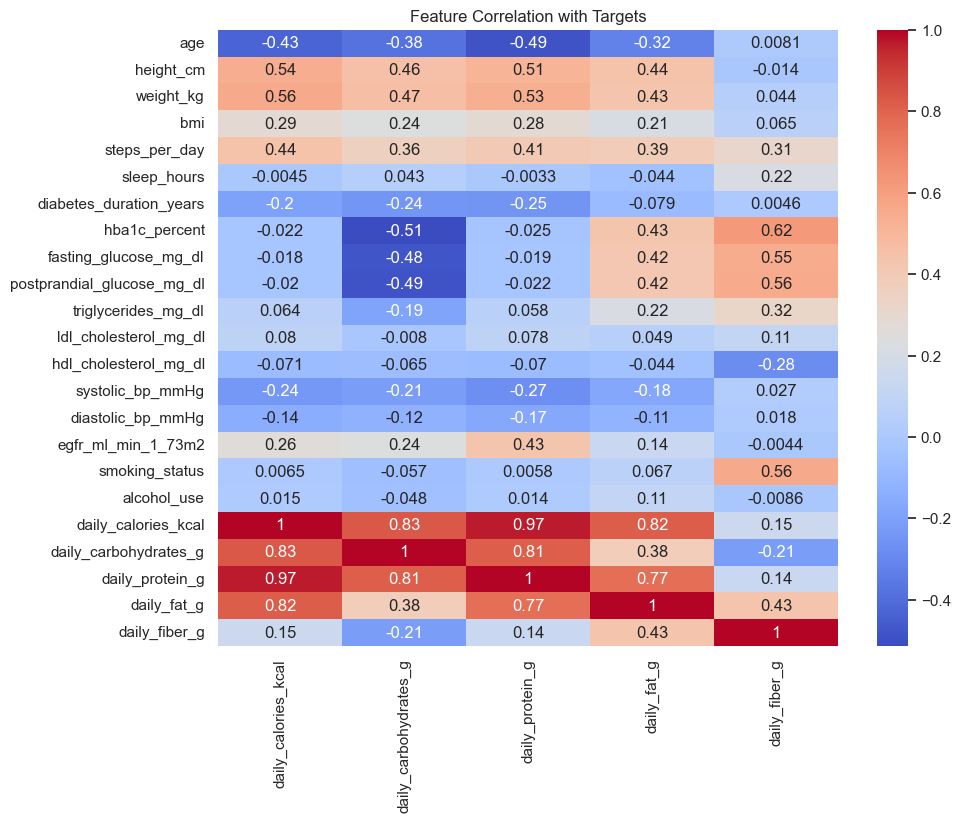

In [11]:
# =====================================================
# TARGET CORRELATION ANALYSIS
# =====================================================

if len(targets_present) > 0:

    target_corr = df[numeric_cols].corr()[targets_present]

    plt.figure(figsize=(10,8))
    sns.heatmap(target_corr, cmap="coolwarm", annot=True)
    plt.title("Feature Correlation with Targets")
    plt.show()

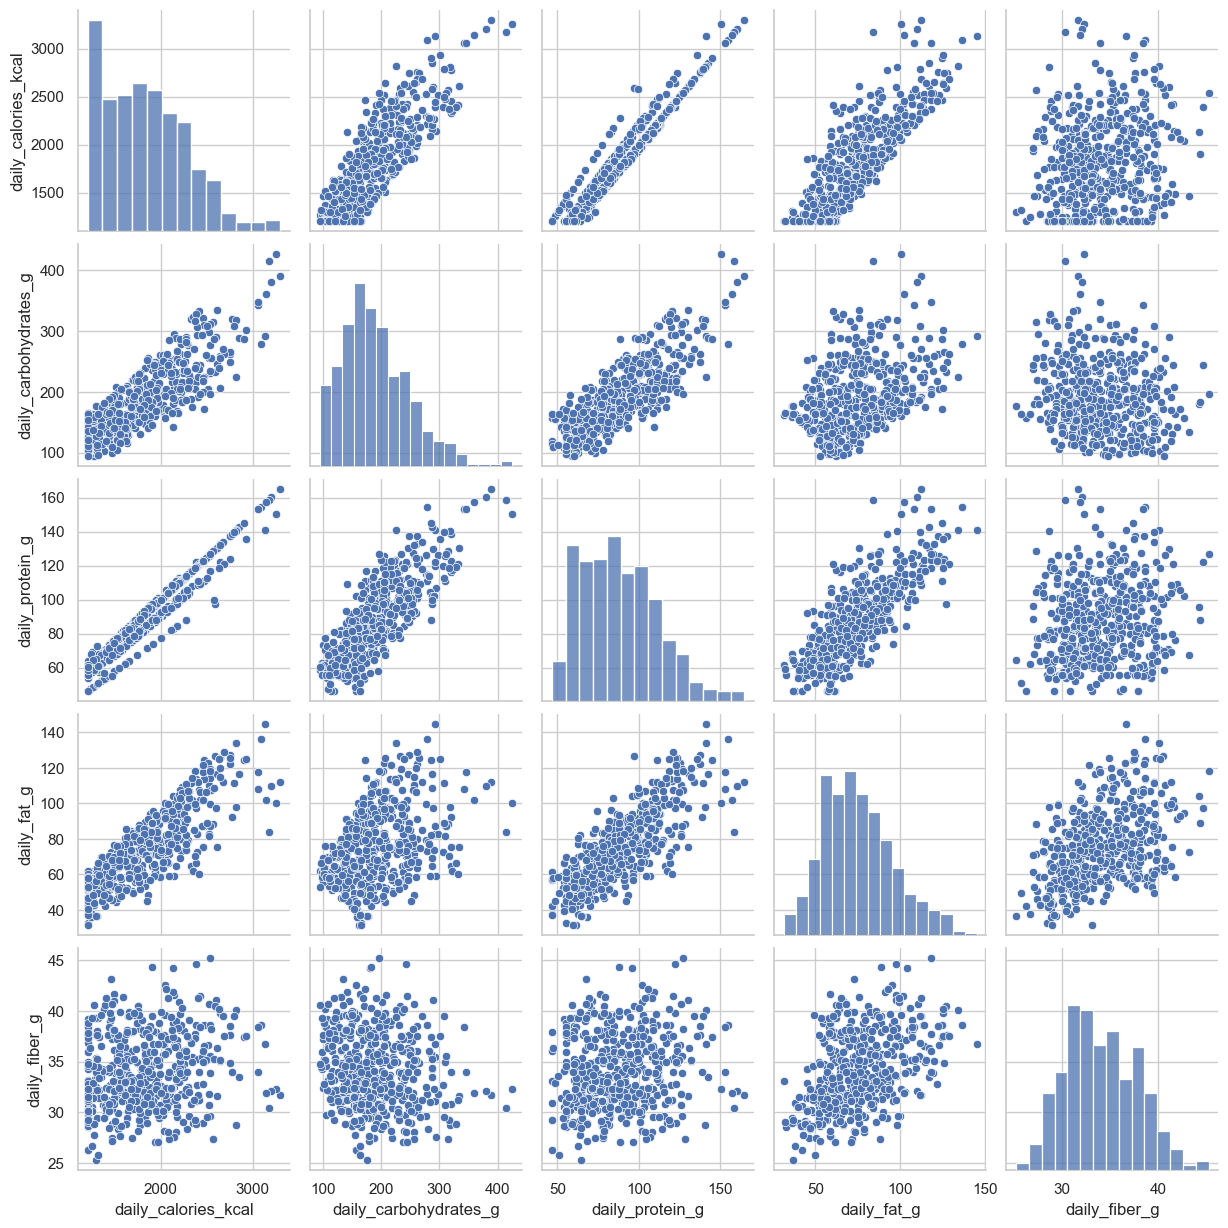

In [12]:
# =====================================================
# PAIRPLOT (SAMPLED)
# =====================================================

sample_df = df.sample(min(500, len(df)), random_state=42)

sns.pairplot(sample_df[targets_present])
plt.show()

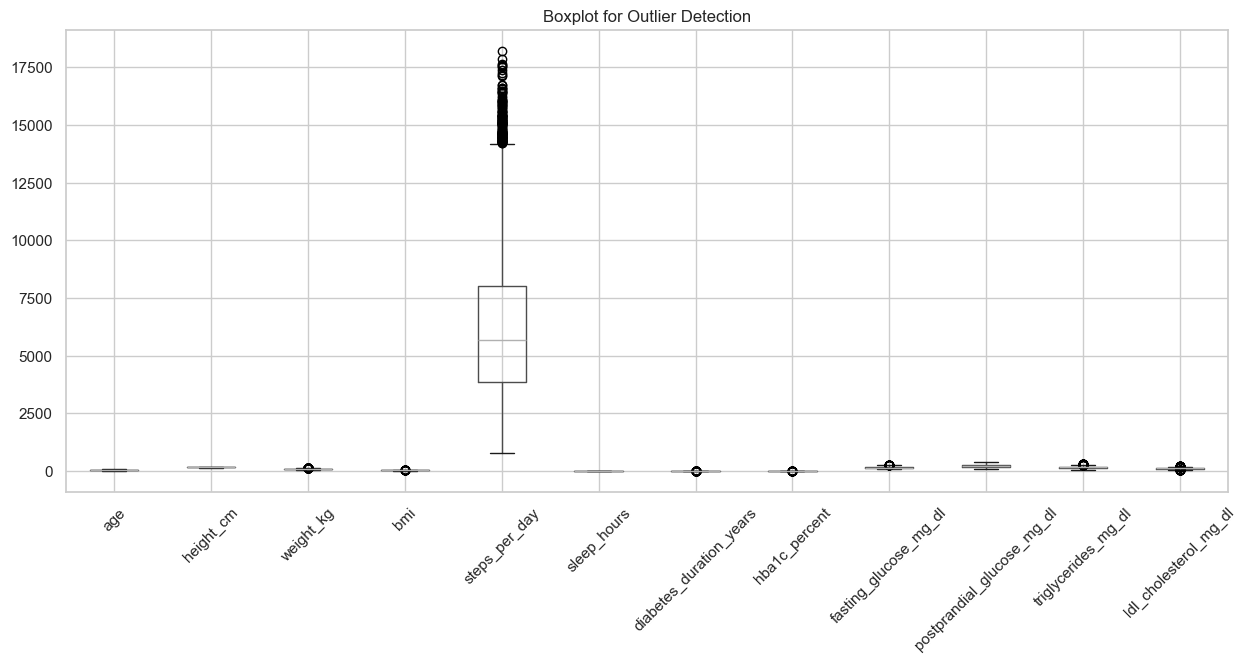

In [13]:
# =====================================================
# OUTLIER CHECK
# =====================================================

num_subset = numeric_cols[:12]

plt.figure(figsize=(15,6))
df[num_subset].boxplot(rot=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [14]:
# =====================================================
# SKEWNESS ANALYSIS
# =====================================================

skewness = df[numeric_cols].skew().sort_values(ascending=False)

print("Top Positively Skewed Features:")
display(skewness.head())

print("Top Negatively Skewed Features:")
display(skewness.tail())

Top Positively Skewed Features:


alcohol_use                1.490104
smoking_status             1.362647
diabetes_duration_years    0.956040
daily_carbohydrates_g      0.809918
steps_per_day              0.719835
dtype: float64

Top Negatively Skewed Features:


bmi                      0.036103
ldl_cholesterol_mg_dl    0.010144
sleep_hours             -0.002442
age                     -0.036553
egfr_ml_min_1_73m2      -0.117521
dtype: float64

In [15]:
! pip install statsmodels

In [16]:
# =====================================================
# ADVANCED EDA IMPORTS
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [17]:
# =====================================================
# PREPARE NUMERIC DATA
# =====================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df_numeric = df[numeric_cols].dropna()

print("Numeric Dataset Shape:", df_numeric.shape)

Numeric Dataset Shape: (10000, 23)


In [18]:
# =====================================================
# VIF MULTICOLLINEARITY CHECK
# =====================================================

X_vif = df_numeric.copy()

X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

display(vif_data)

,Feature,VIF
0,const,15859.094105
19,daily_calories_kcal,233.541702
3,weight_kg,118.571475
20,daily_carbohydrates_g,82.485204
4,bmi,74.567119
21,daily_protein_g,44.766243
2,height_cm,43.427225
22,daily_fat_g,42.744349
8,hba1c_percent,15.926792
23,daily_fiber_g,12.159478


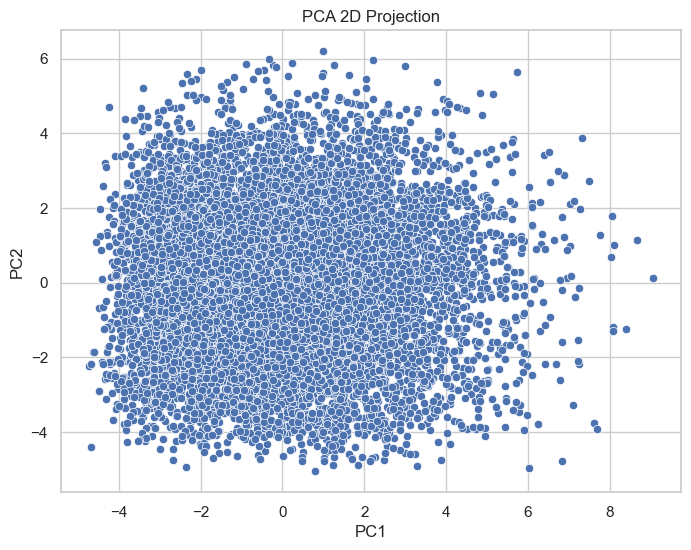

Explained Variance Ratio: [0.21125543 0.17453376]
Total Variance Explained: 0.38578918989867517


In [19]:
# =====================================================
# PCA VISUALIZATION
# =====================================================

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df)
plt.title("PCA 2D Projection")
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

,Feature,Importance
19,daily_protein_g,0.945272
15,egfr_ml_min_1_73m2,0.035980
20,daily_fat_g,0.009487
18,daily_carbohydrates_g,0.004826
2,weight_kg,0.001681
0,age,0.001575
3,bmi,0.000225
11,ldl_cholesterol_mg_dl,0.000133
10,triglycerides_mg_dl,0.000133
1,height_cm,0.000088


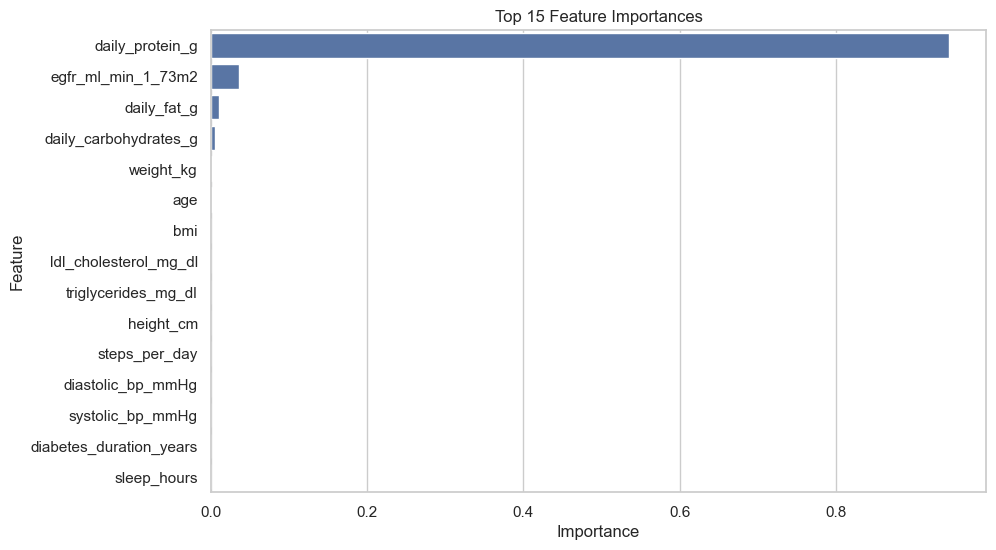

In [20]:
# =====================================================
# FEATURE IMPORTANCE BASELINE
# =====================================================

TARGET_COL = "daily_calories_kcal"  # change if needed

if TARGET_COL in df.columns:
    
    X = df.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number])
    y = df[TARGET_COL]

    X = X.fillna(X.median())
    y = y.fillna(y.median())

    model = RandomForestRegressor(n_estimators=300, random_state=42)
    model.fit(X, y)

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(importance_df.head(15))

    plt.figure(figsize=(10,6))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df.head(15)
    )
    plt.title("Top 15 Feature Importances")
    plt.show()

else:
    print("Target column not found.")

In [21]:
# =====================================================
# NORMALITY TESTS
# =====================================================

normality_results = []

for col in numeric_cols[:15]:  # limit for performance
    stat, p = stats.shapiro(df[col].dropna())
    normality_results.append((col, p))

normality_df = pd.DataFrame(
    normality_results,
    columns=["Feature", "p_value"]
).sort_values(by="p_value")

display(normality_df)

,Feature,p_value
6,diabetes_duration_years,7.162570e-68
0,age,1.154993e-47
4,steps_per_day,5.604591e-45
13,systolic_bp_mmHg,5.577257e-26
7,hba1c_percent,4.542478e-24
2,weight_kg,2.008162e-23
14,diastolic_bp_mmHg,2.235938e-23
1,height_cm,5.479603e-21
12,hdl_cholesterol_mg_dl,1.860990e-20
8,fasting_glucose_mg_dl,2.459655e-19


In [22]:
# =====================================================
# HYPOTHESIS TESTING (Pearson Correlation)
# =====================================================

TARGET_COL = "daily_calories_kcal"

if TARGET_COL in df.columns:

    hypothesis_results = []

    for col in numeric_cols:
        if col != TARGET_COL:
            corr, p_val = stats.pearsonr(
                df[col].fillna(0),
                df[TARGET_COL].fillna(0)
            )
            hypothesis_results.append((col, corr, p_val))

    hypo_df = pd.DataFrame(
        hypothesis_results,
        columns=["Feature", "Correlation", "p_value"]
    ).sort_values(by="p_value")

    display(hypo_df.head(15))

else:
    print("Target column not found.")

,Feature,Correlation,p_value
0,age,-0.430163,0.000000e+00
1,height_cm,0.544086,0.000000e+00
2,weight_kg,0.560501,0.000000e+00
4,steps_per_day,0.442539,0.000000e+00
18,daily_carbohydrates_g,0.830223,0.000000e+00
20,daily_fat_g,0.817583,0.000000e+00
19,daily_protein_g,0.969816,0.000000e+00
3,bmi,0.288640,3.840654e-191
15,egfr_ml_min_1_73m2,0.258530,2.015288e-152
13,systolic_bp_mmHg,-0.235742,2.471895e-126
